In [1]:
import sys
from pyprojroot import here

sys.path.insert(0, str(here()))

import pandas as pd
import numpy as np
import xarray as xr
import pickle
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
import pymc_extras as pmx

import pandas_datareader.data as pdr
import datetime

from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve

from libpysal.weights import KNN, fuzzy_contiguity, w_union, W
import networkx as nx
import warnings

import os
from os.path import exists

import pathlib
from cycler import cycler

import pytensor
from laos_gggi.model import add_data
from laos_gggi.plotting import configure_plot_style

from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data

config = {
    'figure.figsize':(14,4),
    'figure.constrained_layout.use':True,
    'figure.facecolor':'w',
    'axes.grid':False,
    'grid.linewidth':0.5,
    'grid.linestyle':'--',
    'axes.spines.top':False,
    'axes.spines.bottom':False,
    'axes.spines.left':False,
    'axes.spines.right':False
}

plt.rcParams.update(config)


SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [2]:
from laos_gggi import load_shapefile
from laos_gggi.replication_data import create_replication_data
from laos_gggi.data_functions import load_emdat_data, load_all_data
from laos_gggi.sample import sample_or_load

In [3]:
OECD_colors = ["#002F6C", "#7FA8D9", "#006BB6", "#00AACC", "#82D2E3"]
OECD_cycler = cycler(color=OECD_colors)

In [4]:
plt.rcParams.update(
    {
        "axes.prop_cycle": OECD_cycler,
    }
)

In [5]:
# Select SEA countries
laos_neighboors = [
    "KHM",  # Cambodia
    "THA",  # Thailand
    "LAO",  # Laos
    "VNM",  # Vietnam
]

# Data

In [6]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [7]:
# Load maps
world = load_shapefile('world')

# Define maps
sea_map = world.query('ISO_A3 in @laos_neighboors')
laos_map = world.query('ISO_A3 == "LAO"')

# Helper functions

In [8]:
def damage_plot(iso, idata, df, cls='hydro', group='posterior_predictive'):
    fig, ax = plt.subplots()
    data = idata[group].y_hat_damages.sel(obs_iso=iso, obs_disaster_class=cls).groupby('obs_year').mean()

    df = df.replace('Hydrometereological', 'hydro')
    targets = df.query('iso == @iso & disaster_class == @cls').groupby('year')['Total_Damage_Adjusted'].mean().resample('YS').last()

    mu = data.quantile(0.5, dim=['chain', 'draw']).to_dataframe()['y_hat_damages'].resample('YS').last()

    hdi_90 = az.hdi(data, hdi_prob=0.90).y_hat_damages.to_dataframe()['y_hat_damages'].unstack('hdi').resample('YS').last()
    hdi_975 = az.hdi(data, hdi_prob=0.975).y_hat_damages.to_dataframe()['y_hat_damages'].unstack('hdi').resample('YS').last()

    ax.scatter(targets.index, targets.values, color='tab:red', zorder=100)
    ax.scatter(mu.index, mu.values, s=70)

    ax.vlines(mu.index, *hdi_90.values.T, lw=3)
    ax.vlines(mu.index, *hdi_975.values.T)
    ax.grid(ls='--', lw=0.5)
    # ax.set(title = f'{iso} - {cls}')
    plt.close()
    return fig

In [9]:
def plot_predictions(idata, 
                     iso: str,
                     group: str = 'posterior_predictive',
                     var_name: str = 'y_hat',
                     obs_name: str | None = None,
                     data: pd.DataFrame | None = None,
                     **kwargs):
    if group not in ['prior', 'posterior', 'prior_predictive', 'posterior_predictive']:
        raise ValueError(f'Invalid group {group}')
    
    if obs_name and data is None:
        obs_df = idata.observed_data.sel(obs_iso=iso)[obs_name].to_dataframe()[obs_name].drop_duplicates().unstack('disaster')
    elif data is not None:
        obs_df = data.xs(level=0, key=iso)
        
    iso_idata = idata[group][var_name].sel(obs_iso = iso)
    mu = iso_idata.mean(dim=['chain', 'draw'])
    
    index = mu['obs_year'].values
    disasters = ['hydro']
    
    fig, axis = plt.subplots(1, 1, **kwargs)
    
    for disaster in disasters:
        axis.plot(index, mu.sel(disaster=disaster).values, color='tab:blue')

        if obs_name:
            axis.plot(index, obs_df[disaster].values, color='k', marker='o')
    
        for hdi_prob in np.linspace(0.05, 0.95, 25)[::-1]:
            hdi = az.hdi(iso_idata.sel(disaster=disaster), hdi_prob=hdi_prob)[var_name]
            axis.fill_between(index, *hdi.values.T, color='tab:blue', alpha=0.1)
        axis.set(xlabel="Year", ylabel = "Disaster Count", title=f"{iso} {disaster.title()}")
        

    plt.close()
    return fig

In [10]:
def ppc_plot(iso, classes, 
             idata=None,
             predictions=None,
             group='posterior', 
             target='y_hat',
             hdi_lim=1.0):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    
    if idata is None and predictions is None:
        raise ValueError('Need at least one of idata or predictions')
    
    for cls, axis in zip(classes, fig.axes):
        sel = {'obs_iso': iso, 'obs_disaster_class':cls}

        if predictions is None:
            pp = idata[f'{group}_predictive'].sel(obs_iso = iso)
        else:
            pp = predictions['predictions'].sel(obs_iso = iso)
        
        if cls not in pp.coords['obs_disaster_class']:
            axis.set_title(cls)
            continue
        else:
            pp = pp.sel(obs_disaster_class = cls)
        
        if idata is not None:
            obs = idata.observed_data.sel(obs_iso = iso)
            observed = True
        if cls not in obs.coords['obs_disaster_class']:
            obs = pp.copy().mean(dim=['chain', 'draw']) # Dummy data, otherwise plot_ppc throws a fit
            observed=False
        else:
            obs = obs.sel(obs_disaster_class = cls)
        
        pp[target] = pp[target] + np.random.uniform(0, 1e-6, size=pp[target].values.shape)
        
        az.plot_ppc(az.InferenceData(posterior_predictive=pp,
                                     observed_data=obs),
                    ax=axis,
                    var_names=target,
                    observed=observed,
                    legend=False)
            
        axis.set_title(cls)
        
        if hdi_lim < 1.0:
            hdi = az.hdi(pp, hdi_prob=hdi_lim)[target]
            higher = hdi.sel(hdi = 'higher').max()
            axis.set_xlim(0, higher)


### Damage curves model

In [11]:
# Importing cpi data
import pandas as pd
import pandas_datareader.data as pdr
import datetime

# Define the CPI series code for the US
cpi_series_code = 'CPIAUCNS'

# Define the date range
start_date = datetime.datetime(1913, 1, 1)  # CPI data starts from 1913
end_date = datetime.datetime(2025, 12, 31)  # Assuming we want data up to 2025

# Fetch CPI data from FRED
cpi_data = pdr.get_data_fred(cpi_series_code, start_date, end_date)

# Display the fetched data
cpi_2015 = cpi_data.loc['2015-12-01']['CPIAUCNS']
cpi_2025 = cpi_data.loc['2025-01-01']['CPIAUCNS']


In [12]:
def curves_model( coords, df , 
                 codes_idx_joint, 
                 features_events,
                 damage_features_d_stand, 
                 class_idx_joint):
    
    with pm.Model(coords = coords) as model:
        ######################################## event model ########################################
        X_event = pm.Data('X', df[features_events])
        iso_idx_pt = pm.Data('iso_idx', codes_idx_joint, dims=['obs_idx'])
    
        latent_iso_events = pm.Flat('latent_iso_events', dims=['iso', 'features_events'])
        
        # Actual Model    
        country_loc = pm.Flat('country_loc', dims=['disaster'])
        country_scale = pm.Flat('country_scale',dims=['disaster'])
        country_offset = pm.Flat('country_offset', dims=['iso', 'disaster'])
    
        country_effect = pm.Deterministic('country_effect',
                                          country_loc[None] + country_scale[None] * country_offset, 
                                          dims=['iso', 'disaster'])
        
        
        # beta_sigma = 2.5 / df_joint[features_events].std().values[None] * df[disasters].std().values[:, None]
        beta = pm.Flat('beta', dims=['features_events', 'disaster'])
        beta_GY = pm.Flat('beta_GY', dims=['features_events', 'disaster'])    
        coef_effect = X_event @ beta + (latent_iso_events @ beta_GY)[iso_idx_pt]
        mixture = pm.Flat("mixture",
                                   dims = ["iso", 'disaster'])
    
        latent_rate = (country_effect + mixture)[iso_idx_pt] + coef_effect
        mu = pt.softplus(latent_rate)
        
        zero_prob = pm.Flat('zero_prob',dims=['disaster'])
        alpha = pm.Flat('alpha',dims=['disaster'])
        
        y_hat_n_events = pm.ZeroInflatedNegativeBinomial('y_hat_n_events',
                                                psi=zero_prob,
                                                mu=pt.clip(mu, 1e-6, 300),
                                                alpha=alpha,
                                                observed = np.zeros((df.shape[0],2)),
                                                dims= ['obs_idx', 'disaster'])
    
        ######################################## Damages model ########################################
        X_damage = pm.Data('X_damage',   df[damage_features_d_stand], 
                dims=['obs_idx', 'features_damages'])
    
        
        class_idx_pt = pm.Data('class_idx', class_idx_joint, dims=['obs_idx'])
        
        latent_iso_damage = pm.Flat('latent_iso_damage', dims=['iso', 'features_damages'])
        
        country_loc_damage = pm.Flat('country_loc_damage',  dims=['disaster'])
        country_scale_damage = pm.Flat('country_scale_damage', dims=['disaster'])
        country_offset_damage = pm.Flat('country_offset_damage', dims=['iso', 'disaster'])
        country_effect_damage = pm.Deterministic('country_effect_damage', 
                                                 country_loc_damage + country_scale_damage * country_offset_damage,
                                          dims=['iso', 'disaster'])
    
        
        
        beta_damage = pm.Flat('beta_damage', dims=['features_damages', 'disaster'])
        beta_GY_damage = pm.Flat('beta_GY_damage', dims=['features_damages', 'disaster'])    
        coef_effect_damage = X_damage @ beta_damage + (latent_iso_damage @ beta_GY_damage)[iso_idx_pt]
    
        mixture_damage = pm.Flat("mixture_damage",
                                   dims = ["iso", 'disaster'])
    
        mu = ((country_effect_damage + mixture_damage)[iso_idx_pt] + coef_effect_damage)
        
    
        sigma = pm.Flat('sigma', dims=['disaster'])
        
        mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
        mu_damage = pm.Deterministic('mu_damage', pt.concatenate(mus, axis=0), dims=['obs_idx'])
        
        p_zero_damage = pm.Flat('p_zero_damage',dims=['disaster'])
        y_hat_damages = pm.HurdleLogNormal('y_hat_damages',
                       mu=mu_damage,
                       sigma= sigma[class_idx_pt],
                       psi=(1 - p_zero_damage)[class_idx_pt],
                       observed = np.zeros((df.shape[0],)) ,
                       dims=['obs_idx'])
    
        #################################### Damage curves ####################################
        damages_curves = pm.Deterministic("damages_curves", y_hat_damages * y_hat_n_events[: ,1], dims=['obs_idx'])

    return model

In [13]:
from scipy import interpolate


def obtain_base_table(idata, posterior_predictive_input = False, iso='LAO'):
    computed_ry_damage = {}
    curves_df = pd.DataFrame( )
    
    for year in curve_years:
        damages = idata.posterior_predictive.damages_curves.sel(obs_iso=iso,obs_year = year).values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys =   np.repeat(100, 1000000) /np.linspace(0, 100, num=1000000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([0.01, 0.1, 0.2, 0.5, 1, 2, 10, 25, 50, 75]) )
        percentile = np.repeat(100, 1000010) / rys
        year_ = year.year
        computed_ry_damage[year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df = pd.concat([curves_df,computed_ry_damage[year_].T], axis=1)
        
    curves_df= curves_df.reset_index()
    curves_df = curves_df.assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df = curves_df.sort_index(ascending= True)

    return curves_df, percentile


    # Build the return years table
def build_return_years_curve(curves_df ):
    return_years_table = curves_df.loc[np.repeat(100,10)- percentile[-10:]].drop_duplicates()
    
    return_years_table = return_years_table.assign( value = lambda x: (100 / x['percentile_inv']).round(decimals = 1) ) 
    return_years_table = (return_years_table.assign(
        return_years = lambda x:  x['value'].round(0).astype(int).astype(str)  + ' RY' )
                          .drop(columns = ['value', 'percentile_inv']).set_index('return_years',  ))
    return return_years_table.tail(6)

## Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [14]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "square_ln_gdp_pc", 
            "precip_deviation", 
            "co2", 
            "population"]

In [15]:
df.dropna(subset=features, inplace=True)

In [16]:
events_idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'year': 'obs_year', 'iso': 'obs_iso'} ), dim= "obs_idx" )

## Reconcile EMDAT and shapefile ISO codes

In [17]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world['ISO_A3'].unique()

world = world.assign(iso = world.ISO_A3)

In [18]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [19]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'JAM, AND, CYP, ABW, VCT, MCO, GGY, ATF, WLF, MLT, MDV, PRI, TON, BLM, COK, AIA, GIB, IOT, BHS, MAF, FLK, GRL, SGS, NFK, KIR, FSM, LIE, VIR, CYM, PCN, KNA, HMD, PLW, QAT, ISR, SXM, BRB, JEY, COM, SYC, MSR, TTO, CUW, HKG, PSE, SHN, GUM, ASM, NIU, LUX, FRO, NRU, SPM, TUV, BHR, PRK, CPV, DMA, SGP, BMU, IMN, TCA, SMR, VEN, MHL, LCA, UNK, VGB, MNP, ATG, GRD, SLB, MAC, VAT, STP'

In [20]:
# Drop codes not in both
common_codes = set(world_iso).intersection(set(df_iso))

df = df.query('iso in @common_codes').copy()
world = world.query('iso in @common_codes').copy()

In [21]:
# Get unique iso codes and years
code_idx, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)

In [22]:
y = df[disasters].copy().astype(float)

# Assume years without observed disasters had no disasters.
# **THIS IS A TERRIBLE ASSUMPTION **
# but sampling is too onerous without it.
y_filled = y.fillna(0)

# Damage data

In [23]:
emdat = load_emdat_data()

In [24]:
damage_events = (emdat['df_raw_filtered_adj']
           .loc[:, ['Start_Year', 'ISO', 'disaster_class', 'Total_Damage_Adjusted']]
           .dropna()
           .reset_index(drop=True)
           .rename(columns={'Start_Year':'year', 'ISO':'iso'}))

In [25]:
damage_events_full = (damage_events
     .groupby(['iso', 'year', 'disaster_class'])
     .apply(lambda x: x.assign(idx = np.arange(x.shape[0])), 
            include_groups=False)
     .reset_index()
     .set_index(['iso', 'year', 'disaster_class', 'idx']))

# Get unique iso codes and years
_, codes = pd.factorize(damage_events_full.index.get_level_values(0), sort=True)
_, years = pd.factorize(damage_events_full.index.get_level_values(1), sort=True)
_, classes = pd.factorize(damage_events_full.index.get_level_values(2))

power_set = pd.MultiIndex.from_product([codes, years, classes, [0]], names=['iso', 'year', 'disaster_class', 'idx'])
total = pd.MultiIndex.from_tuples(set(power_set.values).union(set(damage_events_full.index)), names=['iso', 'year', 'disaster_class', 'idx'])

damage_events_full = damage_events_full.reindex(total).sort_index().drop(columns=['level_3'])
df_damage_full = (pd.merge(damage_events_full.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage_full['Total_Damage_Adjusted'] = df_damage_full['Total_Damage_Adjusted'] / 1e3

In [26]:
df_damage = (pd.merge(damage_events.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage['Total_Damage_Adjusted'] = df_damage['Total_Damage_Adjusted'] / 1e3

In [27]:
df_damage_full = df_damage_full.query('iso in @df_damage.iso').copy()

In [28]:
# Get unique iso codes and years
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]
rename_dict = {col: f'obs_{col}' for col in idx_cols}

idx_damages = (xr.Coordinates
           .from_pandas_multiindex(df_damage.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))
idx_oos =(xr.Coordinates
           .from_pandas_multiindex(df_damage_full.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))

### Load predictions


In [29]:
# Add prediction data
atmos_pred = pd.read_csv(here('data/CRIforecast.csv'))[['dev_ocean_temp', 'precip_deviation', 'co2', 'time']]
predictions = pd.read_csv(here('data/climate_forecast_lao.csv') )[['gdp_per_cap','Population' , 'time']]
predictions['iso'] = 'LAO'

predictions = pd.merge( atmos_pred, predictions, on ='time').rename(columns = {"time": "Start_Year"})

In [30]:
# Load IPCC data
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

# Create population density
predictions["population_density"] = predictions["Population"] / 236800 * 1e6# Laos area in squared km hardcoded
predictions = predictions.rename(columns = {
                                            'Population': 'population',
                                              'dev_ocean_temp':'dev_from_trend_ocean_temp'})
predictions['year'] = pd.to_datetime(predictions['Start_Year'])

In [31]:
# Calculate logs
predictions["ln_population_density"] = np.log(predictions["population_density"])
predictions["ln_gdp_pc"] = np.log(predictions["gdp_per_cap"])

In [32]:
# Select shorter period
shorter_pred = predictions.set_index(['iso', 'year' ] ).query('2020 < year < 2056')

prediction_dates = shorter_pred.index.get_level_values(1).to_list()

df = pd.concat([df, shorter_pred])

### Standardize data

In [33]:
# Damage features
damage_features_base = ['ln_population_density', 'ln_gdp_pc',
       'precip_deviation', 'co2', 'population']

damage_features_base_d = ['d_' + x for x in damage_features_base]
damage_features_base_d_stand = [x +"__standardized" for x in damage_features_base_d]

for x, d_x in zip(damage_features_base , damage_features_base_d):
    df_damage[d_x] = df_damage[x]

damage_features_d_stand = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'precip_deviation__standardized',
 'co2__standardized',
 'population__standardized',
 ]

# event features
features_events = ["ln_population_density", "ln_gdp_pc", "precip_deviation", "co2", "population" ]


all_features = features_events + damage_features_d_stand 

In [34]:
#Standardize dfs
from laos_gggi.statistics import standardize

transformer_events, df_stand = standardize(df = df, columns = features_events)
transformer_damages, df_damage_stand = standardize(df = df_damage, columns = features_events)


df_joint_stand = pd.DataFrame(transformer_damages.transform(df[features_events]),columns = damage_features_d_stand, index = df.index)

df_joint_stand =  df_joint_stand.join(df )



In [35]:
# Drop duplicates
df_joint_stand = df_joint_stand.drop_duplicates()

# Combine models

In [36]:
#Load idatas
damages_idata  = az.from_netcdf('idata/dmg_5_2025_usd_new_b.nc')
events_idata  = az.from_netcdf('idata/freq_model_4_1000d.nc')

damage_idata_2 = damages_idata.copy()


#Rename to avoid conflicts merging
events_idata = events_idata.rename({'latent_iso': 'latent_iso_events',
                                    })


damages_idata = damages_idata.rename({"country_loc": "country_loc_damage",
                                     'country_scale': 'country_scale_damage',
                                     'country_offset': 'country_offset_damage',
                                     'country_effect':'country_effect_damage',
                                      'beta': 'beta_damage',
                                      'beta_GY': 'beta_GY_damage',
                                      'mixture': 'mixture_damage',
                                      'alpha_X': 'alpha_X_damage',
                                      'latent_iso': 'latent_iso_damage',
                                      'phi': 'phi_damage',
                                      'phi_climatological_disasters': 'phi_climatological_disasters_damage',
                                      'phi_hydrological_disasters': 'phi_hydrological_disasters_damage',
                                      'rho': 'rho_damage',
                                      'sigma_X': 'sigma_X_damage',
                                      'theta': 'theta_Damage',
                                      'p_zero': 'p_zero_damage',
                                      'mu': 'mu_damage',
                                    })

#Merge posteriors
merged_posteriors_0 = xr.merge([damages_idata.posterior.drop_vars(['mu_damage'] ).drop_dims('obs_idx'),
                              events_idata.posterior])

In [37]:
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]

In [38]:
# iso codes
code_idx, codes = pd.factorize(df.reset_index()['iso'], sort=True)
codes_to_idx = {name: idx for idx, name in enumerate(codes)}
codes_idx_joint=  df_joint_stand.reset_index()['iso'].map(codes_to_idx.get)

# class codes
class_idx, classes = pd.factorize( df_damage['disaster_class'].replace({'Hydrometereological': 'hydro', 
                                                                      'Climatological': 'climate'} ))
class_to_idx = {name: idx for idx, name in enumerate(classes)}

df_joint_stand['disaster_class'] = 'hydro'
class_idx_joint =  df_joint_stand['disaster_class'].map(class_to_idx.get)

# years
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)
year_to_idx = {name: idx for idx, name in enumerate(years)}
year_idx_joint =  df_joint_stand.index.get_level_values("year").map(year_to_idx.get)

national_features = list(filter(lambda x: x != 'co2__standardized', damage_features_d_stand))
world_features = ['co2__standardized']

training_years = [dt.year for dt in years]

coords_combined = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df_joint_stand.shape[0]),
    'features_events':features_events,
    'features_damages': damage_features_d_stand,
    'world_feature': world_features,
    'national_feature': national_features,
    'fixed_effect': ['iso', 'year'],
    'latent': ['iso', 'year'],
    'year_os' :  [ dt.year for dt in list(years) + prediction_dates]
}


# Combine coords
combined_xr_idx =( xr.Coordinates.from_pandas_multiindex(df_joint_stand.reset_index().set_index(['iso', 'year', 'disaster_class'])
                                                         .index.rename({'iso':'obs_iso', 
                                                                        'year':'obs_year',
                                                                        'disaster_class': 'obs_disaster_class'}), 'obs_idx'))

base_df_joint_stand = df_joint_stand.copy()

In [39]:
#Combined

combined_model = curves_model(coords = coords_combined , df = df_joint_stand ,
                                codes_idx_joint = codes_idx_joint,
                                features_events = features_events,
                                damage_features_d_stand= damage_features_d_stand,
                                class_idx_joint = class_idx_joint )


In [40]:
from pymc.model.transform.optimization import freeze_dims_and_data

file_name = 'idata/idata_post_combined_1.pkl'

if exists(file_name):
    with open(file_name, 'rb') as f:
        idata_post_combined = pickle.load(f)
else:
    with freeze_dims_and_data(combined_model ) :
        idata_post_combined = pm.sample_posterior_predictive(merged_posteriors_0 , extend_inferencedata=False, 
                                                          compile_kwargs={'mode':'JAX'},
                                                    var_names=[ 
                                                        'damages_curves', 
                                                               'y_hat_damages',
                                                        'y_hat_n_events']
                                                           )
    
        idata_post_combined = idata_post_combined.assign_coords(combined_xr_idx)
        with open(file_name, 'wb') as f:
            pickle.dump(idata_post_combined, f)

In [41]:
curve_years =prediction_dates = [pd.to_datetime('2000-01-01 00:00:00'),
                    pd.to_datetime('2010-01-01 00:00:00'),
                    pd.to_datetime('2018-01-01 00:00:00'), 
                    pd.to_datetime('2030-01-01 00:00:00'),
                    pd.to_datetime('2045-01-01 00:00:00'),
                    pd.to_datetime('2055-01-01 00:00:00'),]

# Plots Lao

In [42]:
# Compute base table
curves_df, percentile = obtain_base_table(idata_post_combined, iso = 'LAO')

C:\Users\camil\AppData\Local\Temp\ipykernel_76308\2361601720.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 1000000) /np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_76308\2361601720.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 1000000) /np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_76308\2361601720.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 1000000) /np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_76308\2361601720.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 1000000) /np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_76308\2361601720.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 1000000) /np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_76308\23616

C:\Users\camil\AppData\Local\Temp\ipykernel_76308\18865680.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


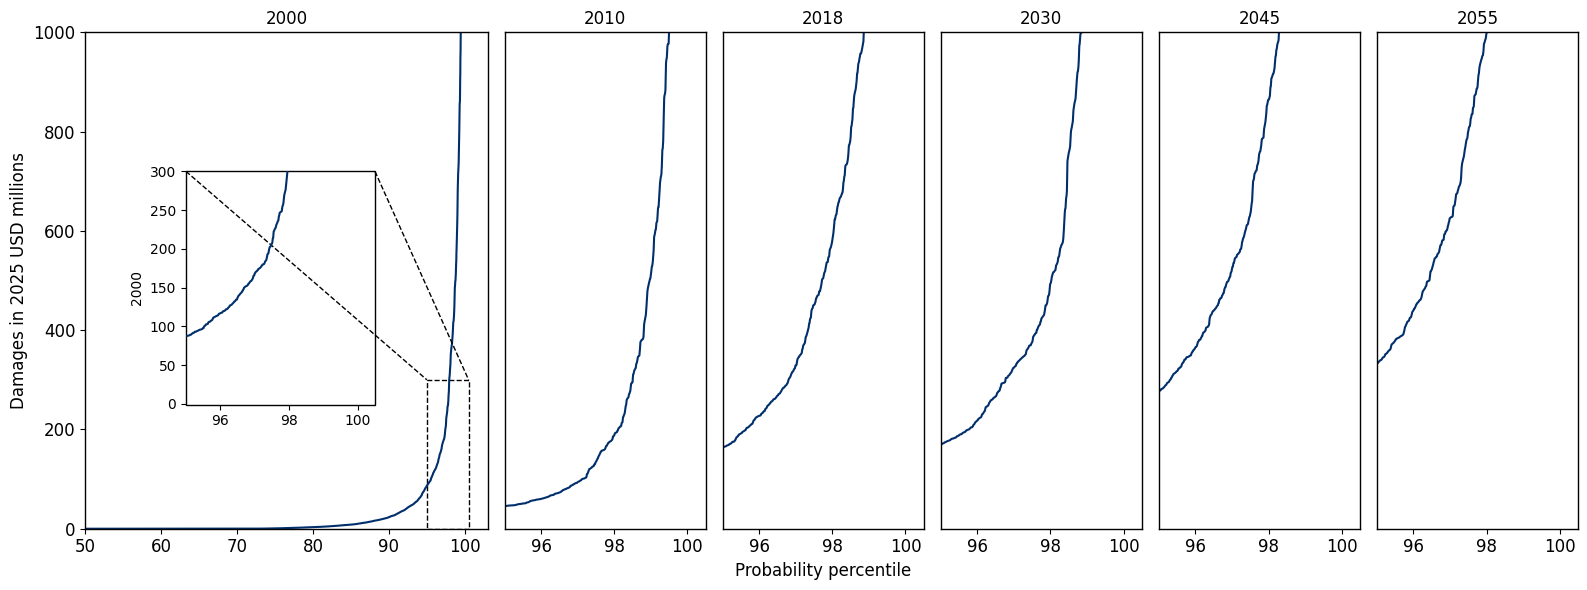

In [43]:
# Plot damage curves
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6))

# Create a GridSpec with custom width ratios
gs = gridspec.GridSpec(1, 6, width_ratios=[2, 1, 1, 1, 1, 1])

# Create axes using the GridSpec
axes = [fig.add_subplot(gs[0, i]) for i in range(6)]

# y_axes_lim = [curves_df['2005'].min() , curves_df['2005'].max() - (curves_df['2005'].min() *0.15) ]
y_axes_lim = [curves_df['2000'].min() , 1000 ]
x_axes_lim = [95, 100.5]

# Plot the first subplot with a larger width
sns.lineplot(data=curves_df, x=list(curves_df.index), y=f'{curve_years[0].year}', ax=axes[0])
axes[0].set_title(f'{curve_years[0].year}', fontsize=12)
axes[0].set_ylabel('Damages in 2025 USD millions', fontsize=12)
axes[0].set_xlabel('Probability percentile', fontsize=12)
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].set_xlim([50, x_axes_lim[1] +2.5] )
axes[0].set_ylim( y_axes_lim[0], y_axes_lim[1] )

# Create an inset axes for zooming in on Y > 0
axins = axes[0].inset_axes([0.25, 0.25, 0.47, 0.47],  )

# Set inset background color (optional) and border color
axins.patch.set_facecolor('white')  # Ensures inset is visible
axins.patch.set_edgecolor('black')  # Sets outer edge color
axins.patch.set_linewidth(1)  # Adjusts edge thickness

# Filter the data for Y > 0 and plot on the inset axes
filtered_data = curves_df[curves_df[f'{curve_years[0].year}'] > 0]
sns.lineplot(data=filtered_data, x=list(filtered_data.index), y=f'{curve_years[0].year}', ax=axins)

# Set limits for the inset axes
axins.set_xlim(95, 100.5)  # Adjust as needed
axin_y_max = 300
axins.set_ylim(-1,axin_y_max)  # Adjust as needed

# Mark the inset region on the original plot
mark_inset(axes[0], axins, loc1=2, loc2=1, fc="none",ec="black",  linestyle = '--', )
# mark_inset(axes[0], axins, loc1=3, loc2=3, fc="none",ec="black",  linestyle = '--', )

# Plot the remaining subplots
for year, n in zip(curve_years[1:], range(1, 6)):
    sns.lineplot(data=curves_df, x=list(curves_df.index), y=f'{year.year}', ax=axes[n])
    axes[n].set_title(f'{year.year}', fontsize=12)
    axes[n].set_xlabel('Probability percentile', fontsize=12)
    axes[n].tick_params(axis='both', which='major', labelsize=12)
    axes[n].set_xlim([x_axes_lim[0], x_axes_lim[1]])
    axes[n].set_yticks([])
    axes[n].set_ylim(y_axes_lim[0],  y_axes_lim[1])
    axes[n].set_ylabel('', fontsize=12)
    
for x in range(0,6):
    for spine in ['bottom', 'top',  'right', 'left']:
        axes[x].spines[spine].set_visible(True)    
        axes[x].spines[spine].set_color('black')    
        axes[x].spines[spine].set_linewidth(1)     #
        if x !=2:
            axes[x].set_xlabel("")


plt.tight_layout()
# fig.savefig(here('notebooks/final_paper/figures_and_plots/results') / 'damage_curves_lao.png', format = 'png', bbox_inches='tight');
plt.show()

In [44]:
# Build the return years table
return_years_table =  build_return_years_curve( curves_df=  curves_df) 

# return_years_table.to_csv(here('data/return_years_table_final_lak.csv'))
return_years_table.round(2)

,2000,2010,2018,2030,2045,2055
return_years,,,,,,
100 RY,611.19,511.82,1195.83,1187.81,1623.36,2133.86
50 RY,307.86,188.15,581.92,493.46,864.37,997.77
10 RY,23.38,11.46,52.44,57.22,90.29,117.28
4 RY,0.72,0.00,3.47,5.39,10.58,13.53
2 RY,0.00,0.00,0.00,0.00,0.00,0.00
1 RY,0.00,0.00,0.00,0.00,0.00,0.00


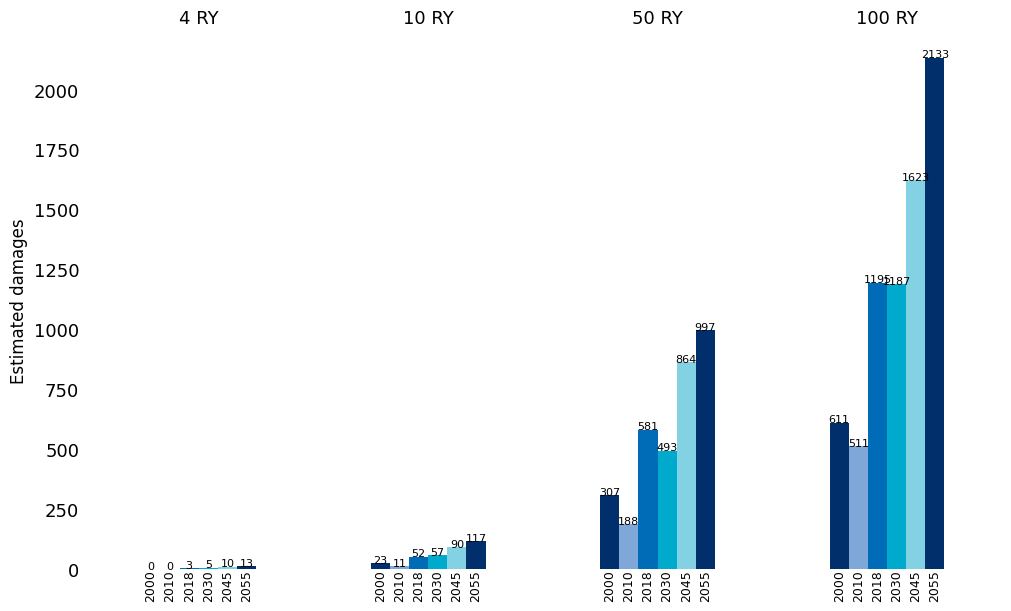

In [45]:
import matplotlib.pyplot as plt
import numpy as np
years_plot = [x.year for x in prediction_dates]

# Create the figure and axis
fig, axes = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

# Define the colormap
cmap = plt.get_cmap('crest')

data_plot = return_years_table.head(4).reset_index().sort_index(ascending = False).set_index('return_years')

# Sample more distinct colors from the colormap
# num_colors = data_plot.shape[1]
# colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]

# Plot the data with the modified colormap
bars =data_plot.plot(
    kind='bar',
    ax=axes,
    color=OECD_colors
)


# Add value labels with vertical separation
label_offset = 0.1  # Horizontal offset from the bar
vertical_offset = 0  # Vertical offset between labels

for bar_container in bars.containers:
    for i, bar in enumerate(bar_container):
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        y_pos = height + label_offset  # Adjust label_offset as needed
        axes.text(x_pos, y_pos, f'{int(height)}', fontsize=8, color='black', ha='center')


# Add year labels below each bar
for bar_container, year in zip(bars.containers, years_plot):
    for bar in bar_container:
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        y_pos = -label_offset  # Position below the bar
        axes.text(x_pos, y_pos, f'{year}', fontsize=9, color='black', ha='center', va='top', rotation = 90)


# Set the legend manually
handles, labels = axes.get_legend_handles_labels()
axes.get_legend().remove()

# Set axis labels
axes.set_ylabel('Estimated damages', fontsize=12)
axes.set_xlabel('')
axes.tick_params(axis='both', which='major', labelsize=13,length=0)
axes.set_xticklabels(axes.get_xticklabels(), rotation=0)
axes.xaxis.set_ticks_position('top')
axes.xaxis.set_label_position('top');

# fig.savefig(here('notebooks/final_paper/figures_and_plots/results') / 'damagecurves_barplots_lao.png', format = 'png', bbox_inches='tight');

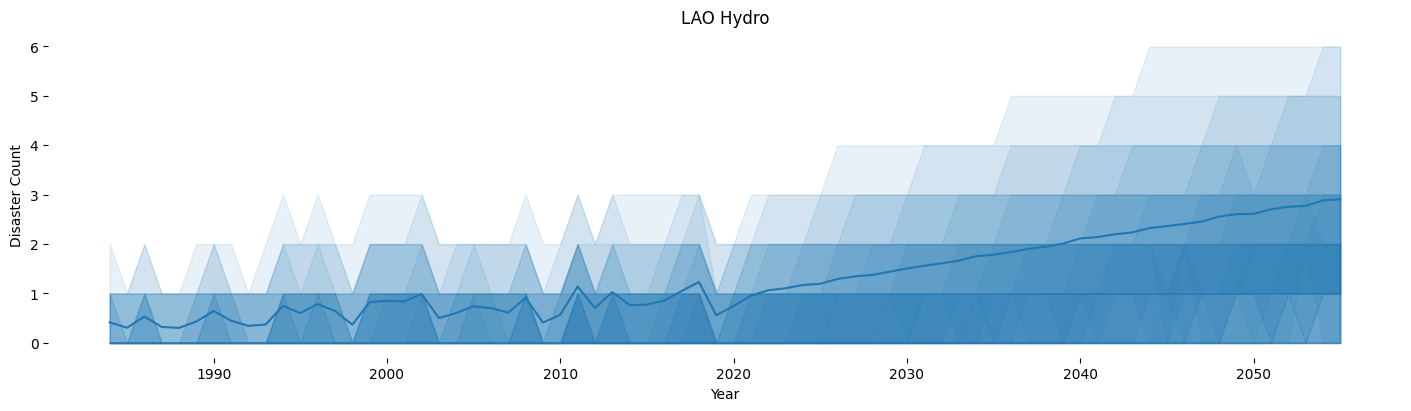

In [46]:
pred_fig = plot_predictions(idata_post_combined, 'LAO', 
                 'posterior_predictive',
                 obs_name= None, 
                 var_name= 'y_hat_n_events',
                 data= None)
# pred_fig.savefig(here('notebooks/final_paper/figures_and_plots/results') / 'result_event_freq_pred_lao.png', format = 'png', bbox_inches='tight')
pred_fig

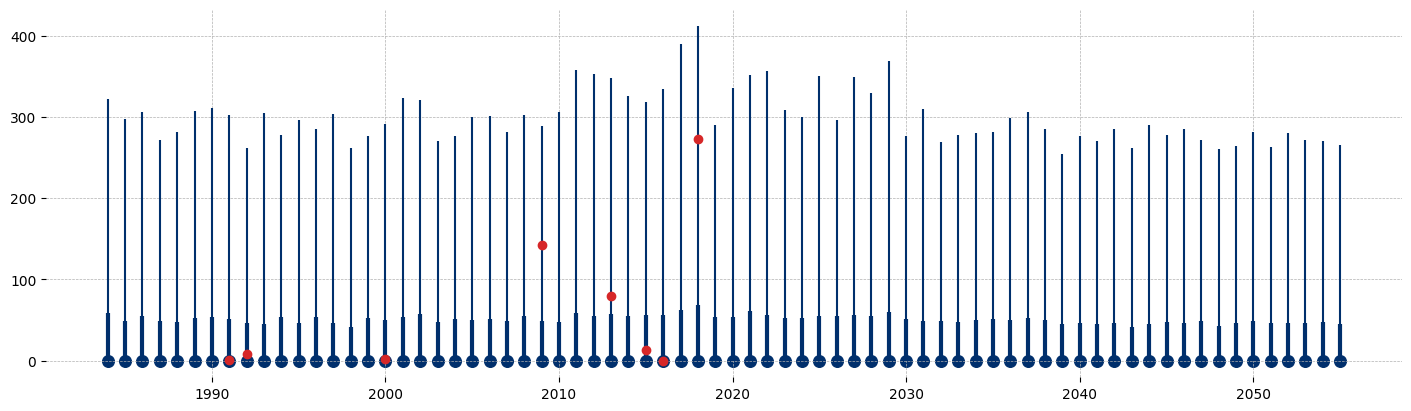

In [47]:
fig_lao = damage_plot('LAO', idata_post_combined, df_damage, group='posterior_predictive', cls='hydro')
# fig_lao.savefig(here('notebooks/final_paper/figures_and_plots/results') / 'result_damages_lao.png', format = 'png', bbox_inches='tight');

fig_lao